In [ ]:
import csv
import time
from selenium import webdriver 
from webdriver_manager.chrome import ChromeDriverManager 
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

In [ ]:
# Configuration WebDriver
options = webdriver.ChromeOptions()
service = Service(ChromeDriverManager().install())
browser = webdriver.Chrome(service=service, options=options)


# Aller sur Alibaba
browser.get('https://www.ebay.fr/')
time.sleep(3)


In [ ]:
# Recherche
browser.find_element(By.CSS_SELECTOR, ".gh-search-input.gh-tb.ui-autocomplete-input").send_keys("laptop")
browser.find_element(By.CSS_SELECTOR, ".gh-search-button__wrap").click()
time.sleep(5)

In [ ]:
Product_titles = browser.find_elements(By.CSS_SELECTOR, ".su-styled-text.primary.default")
titles = [title.text.strip() for title in Product_titles]
print(titles)

In [ ]:
prices = browser.find_elements(By.CSS_SELECTOR, ".su-styled-text.primary.bold.large-1.s-card__price")
price = [price.text.strip() for price in prices]
print(price)

In [ ]:
links_elements = browser.find_elements(By.XPATH, "//a[contains(@href,'/itm/')]")
urls = [link.get_attribute('href') for link in links_elements if link.get_attribute('href')]
print(urls)
time.sleep(5)

In [ ]:
# On sauvegarde les infos AVANT de changer de page
from os import link


produits = []
for i in range(min(len(Product_titles), len(price), len(urls))):
    Product = titles[i]
    prix = price[i]
    url = urls[i]
    produits.append({
        "idProduits": i+1,
        "titles": Product,
        "price":prix,
        "urls":url
    })



In [ ]:
def get_description_from_product(urls):
    browser.get(urls)
    try:
        descriptions = browser.find_elements(By.CSS_SELECTOR, ".x-item-description-child")
        descriptive = [desc.text.strip() for desc in descriptions]
        return descriptive
    except Exception as e:
        print(f"Erreur sur {urls}: {e}")
        return []
    


In [ ]:
def get_comments_from_product(urls):
    browser.get(urls)
    try:
        comments = browser.find_elements(By.CSS_SELECTOR, ".fdbk-container__details__comment span")
        comment = [comm.text.strip() for comm in comments]
        return comment
    except Exception as e:
        print(f"Erreur sur {urls}: {e}")
        return []

In [ ]:
resultats = []

for produit in produits:
    print(f"Produit {produit['idProduits']} : {produit['titles']} : {produit['price']} {produit['urls']}")

    commentaires = get_comments_from_product(produit["urls"])
    descriptions = get_description_from_product(produit["urls"])

    resultats.append({
        "idProduits": produit["idProduits"],
        "titles": produit["titles"],
        "price": produit["price"],
        "urls": produit['urls'],
        "commentaire": " | ".join(commentaires) if commentaires else "",
        "description": " | ".join(descriptions) if descriptions else ""
    })

else:

    resultats.append({
    
        "idProduits": produit["idProduits"],
        "titles": produit["titles"],
        "price": produit['price'],
         "urls": produit['urls'],
        "commentaire": "",
         "description": ""
        })
        
print("عدد النتائج:", len(resultats))



In [ ]:
# Enregistrement dans un CSV
with open("resultatsEbay.csv", mode="w", newline="", encoding="utf-8") as fichier_csv:
    champs = ["idProduits", "titles", "price", "urls", "description", "commentaire"]
    writer = csv.DictWriter(fichier_csv, fieldnames=champs)
    writer.writeheader()
    for ligne in resultats:
        writer.writerow(ligne)

print("Fichier 'resultats3.csv' créé avec succès.")

In [1]:
import pandas as pd

In [2]:
df= pd.read_csv("resultatsEbay.csv")
df

,idProduits,titles,price,urls,description,commentaire
0,1,NaN,NaN,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,NaN
1,2,NaN,NaN,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,NaN
2,3,"Lenovo ThinkPad T14 G2 14"" Intel i5-1145G7 16G...","290,00 EUR",https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,NaN
3,4,LENOVO IDEAPAD SLIM 7 14ITL05 Laptop Intel i5-...,"67,25 EUR",https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,NaN
4,5,"Asus Touch Chromebook Flip 14"" i3 1.80GHz/8GB/...","105,55 EUR",https://www.ebay.fr/itm/187816520966?_skw=lapt...,NaN,"Good product , looks like new , seller was ver..."
...,...,...,...,...,...,...
63,64,"B Dell Latitude 7420 14"" Laptop i5-11th Gen 4....","587,64 EUR",https://www.ebay.fr/itm/366041275686?_skw=lapt...,NaN,| ⭐️⭐️⭐️⭐️⭐️ Avis très positif sur ce vendeur...
64,65,Linkedin Premium Career - 3 MONTHS -,"773,43 EUR",https://www.ebay.fr/itm/326997120644?_skw=lapt...,NaN,The shipping was lightning fast (I got it in o...
65,66,"Asus F515E VivoBook 15.6”FullHD Laptop,Intel i...","126,09 EUR",https://www.ebay.fr/itm/326997120644?_skw=lapt...,NaN,The shipping was lightning fast (I got it in o...
66,67,"Dell Latitude 5520 15"" FHD Intel Core i5-1135G...","168,13 EUR",https://www.ebay.fr/itm/198097473069?_skw=lapt...,NaN,"Fast shipping, excellent packaging, item recei..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   idProduits   68 non-null     int64  
 1   titles       66 non-null     object 
 2   price        66 non-null     object 
 3   urls         68 non-null     object 
 4   description  0 non-null      float64
 5   commentaire  60 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 3.3+ KB


In [4]:
df.shape

(68, 6)

In [5]:
df.isna().sum()

idProduits      0
titles          2
price           2
urls            0
description    68
commentaire     8
dtype: int64

In [6]:
df["titles"] = df["titles"].fillna(" ")
df["commentaire"] = df["commentaire"].fillna(" ")

In [7]:
df.isna().sum()

idProduits      0
titles          0
price           2
urls            0
description    68
commentaire     0
dtype: int64

In [8]:
import numpy as np
df["price"] = df["price"].replace(["NaN"], np.nan)

In [9]:
df["price"] = df["price"].str.replace("EUR", "")
df["price"] = df["price"].str.strip()
df["price"] = df["price"].str.replace(",", ".")


In [10]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [11]:
df.dtypes

idProduits       int64
titles          object
price          float64
urls            object
description    float64
commentaire     object
dtype: object

In [13]:
df.isna().sum()

idProduits      0
titles          0
price           5
urls            0
description    68
commentaire     0
dtype: int64

In [14]:
df['price']=df['price'].fillna(df['price'].median())
df

,idProduits,titles,price,urls,description,commentaire
0,1,,168.13,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,
1,2,,168.13,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,
2,3,"Lenovo ThinkPad T14 G2 14"" Intel i5-1145G7 16G...",290.00,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,
3,4,LENOVO IDEAPAD SLIM 7 14ITL05 Laptop Intel i5-...,67.25,https://ebay.com/itm/123456?itmmeta=012DEW30YG...,NaN,
4,5,"Asus Touch Chromebook Flip 14"" i3 1.80GHz/8GB/...",105.55,https://www.ebay.fr/itm/187816520966?_skw=lapt...,NaN,"Good product , looks like new , seller was ver..."
...,...,...,...,...,...,...
63,64,"B Dell Latitude 7420 14"" Laptop i5-11th Gen 4....",587.64,https://www.ebay.fr/itm/366041275686?_skw=lapt...,NaN,| ⭐️⭐️⭐️⭐️⭐️ Avis très positif sur ce vendeur...
64,65,Linkedin Premium Career - 3 MONTHS -,773.43,https://www.ebay.fr/itm/326997120644?_skw=lapt...,NaN,The shipping was lightning fast (I got it in o...
65,66,"Asus F515E VivoBook 15.6”FullHD Laptop,Intel i...",126.09,https://www.ebay.fr/itm/326997120644?_skw=lapt...,NaN,The shipping was lightning fast (I got it in o...
66,67,"Dell Latitude 5520 15"" FHD Intel Core i5-1135G...",168.13,https://www.ebay.fr/itm/198097473069?_skw=lapt...,NaN,"Fast shipping, excellent packaging, item recei..."


In [15]:
df.isnull().sum()

idProduits      0
titles          0
price           0
urls            0
description    68
commentaire     0
dtype: int64

# Data Cleaning & Preparation

We clean textual and numerical fields to ensure consistency before applying text mining techniques.

In [16]:
df = df.drop_duplicates(subset=["titles"], keep="first")

Duplicate titles were removed to prevent artificial inflation of similarity scores.

In [17]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


nltk.download("wordnet", quiet=True)
nltk.download("stopwords")
stop_words = set(stopwords.words('english') + stopwords.words('french'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
TEXT_COLUMNS = ["titles", "commentaire"]

for col in TEXT_COLUMNS:
    cleaned_texts = []
    for text in df[col].fillna("").astype(str):
        text = text.lower()
        text = re.sub(r"\d+", " ", text)
        text = re.sub(r"[^\w\s]", " ", text)
        words = text.split()
        words = [w for w in words if w not in stop_words]
        cleaned_texts.append(words)

    df[col + "_clean"] = cleaned_texts

print(df[[c + "_clean" for c in TEXT_COLUMNS]])



                                         titles_clean  \
0                                                  []   
2   [lenovo, thinkpad, g, intel, g, gb, ram, gb, s...   
3   [lenovo, ideapad, slim, itl, laptop, intel, g,...   
4   [asus, touch, chromebook, flip, ghz, gb, gb, s...   
5               [perplexity, pro, year, code, global]   
..                                                ...   
62     [hp, elitebook, g, notebook, pc, windows, pro]   
63  [b, dell, latitude, laptop, th, gen, ghz, gb, ...   
64                [linkedin, premium, career, months]   
65  [asus, f, e, vivobook, fullhd, laptop, intel, ...   
66  [dell, latitude, fhd, intel, core, g, ghz, gb,...   

                                    commentaire_clean  
0                                                  []  
2                                                  []  
3                                                  []  
4   [good, product, looks, like, new, seller, fast...  
5   [good, product, looks, like, ne

C:\Users\PC\AppData\Local\Temp\ipykernel_10392\2444762000.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + "_clean"] = cleaned_texts
C:\Users\PC\AppData\Local\Temp\ipykernel_10392\2444762000.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + "_clean"] = cleaned_texts


In [19]:

# LEMMATIZATION
for col in TEXT_COLUMNS:
    df[col + "_lemma"] = df[col + "_clean"].apply(
        lambda words: [lemmatizer.lemmatize(w) for w in words]
    )

print("\n LEMMATIZATION")
print(df[[c + "_lemma" for c in TEXT_COLUMNS]])


 LEMMATIZATION
                                         titles_lemma  \
0                                                  []   
2   [lenovo, thinkpad, g, intel, g, gb, ram, gb, s...   
3   [lenovo, ideapad, slim, itl, laptop, intel, g,...   
4   [asus, touch, chromebook, flip, ghz, gb, gb, s...   
5               [perplexity, pro, year, code, global]   
..                                                ...   
62      [hp, elitebook, g, notebook, pc, window, pro]   
63  [b, dell, latitude, laptop, th, gen, ghz, gb, ...   
64                 [linkedin, premium, career, month]   
65  [asus, f, e, vivobook, fullhd, laptop, intel, ...   
66  [dell, latitude, fhd, intel, core, g, ghz, gb,...   

                                    commentaire_lemma  
0                                                  []  
2                                                  []  
3                                                  []  
4   [good, product, look, like, new, seller, fast,...  
5   [good, product,

C:\Users\PC\AppData\Local\Temp\ipykernel_10392\1129325508.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + "_lemma"] = df[col + "_clean"].apply(
C:\Users\PC\AppData\Local\Temp\ipykernel_10392\1129325508.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + "_lemma"] = df[col + "_clean"].apply(


In [22]:
df["all_text"] = df[[c + "_lemma" for c in TEXT_COLUMNS]] \
    .apply(lambda row: " ".join(sum(row, [])), axis=1)

print("\n MERGED TEXT")
print(df["all_text"])


 MERGED TEXT
0                                                      
2     lenovo thinkpad g intel g gb ram gb ssd full h...
3     lenovo ideapad slim itl laptop intel g gb ram ...
4     asus touch chromebook flip ghz gb gb ssd cx fm...
5     perplexity pro year code global good product l...
                            ...                        
62    hp elitebook g notebook pc window pro avis trè...
63    b dell latitude laptop th gen ghz gb nvme gb r...
64    linkedin premium career month shipping lightni...
65    asus f e vivobook fullhd laptop intel g gb ram...
66    dell latitude fhd intel core g ghz gb ram gb s...
Name: all_text, Length: 63, dtype: object


C:\Users\PC\AppData\Local\Temp\ipykernel_10392\1176518687.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["all_text"] = df[[c + "_lemma" for c in TEXT_COLUMNS]] \


In [23]:
 
#  BAG OF WORDS

bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df["all_text"])
df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())

print("\n BAG OF WORDS MATRIX")
print(df_bow)



 BAG OF WORDS MATRIX
    aaa  ab  abbastanza  aber  abgebildet  able  absolut  absolute  \
0     0   0           0     0           0     0        0         0   
1     0   0           0     0           0     0        0         0   
2     0   0           0     0           0     0        0         0   
3     0   0           0     0           0     0        0         0   
4     0   0           0     0           0     0        0         0   
..  ...  ..         ...   ...         ...   ...      ...       ...   
58    0   0           0     0           0     0        0         1   
59    0   0           0     0           0     0        0         1   
60    0   0           0     0           0     0        0         0   
61    0   0           0     0           0     0        0         0   
62    0   0           0     0           0     0        0         0   

    absolutely  abwicklung  ...  wurde  wuxga  xbox  ya  year  yoga  zu  \
0            0           0  ...      0      0     0   0     0 

In [24]:
print(bow_vectorizer.get_feature_names_out())

['aaa' 'ab' 'abbastanza' ... 'zufriedenstellend' 'zustand' 'état']


In [25]:

#  TF-IDF

tfidf_vectorizer = TfidfVectorizer(max_df=0.8, min_df=2, max_features=3000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(df["all_text"])

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("\n TF-IDF MATRIX")
print(df_tfidf)



 TF-IDF MATRIX
    aaa   ab  ab canada  aber  aber dafür  able use  absolut  \
0   0.0  0.0        0.0   0.0         0.0       0.0      0.0   
1   0.0  0.0        0.0   0.0         0.0       0.0      0.0   
2   0.0  0.0        0.0   0.0         0.0       0.0      0.0   
3   0.0  0.0        0.0   0.0         0.0       0.0      0.0   
4   0.0  0.0        0.0   0.0         0.0       0.0      0.0   
..  ...  ...        ...   ...         ...       ...      ...   
58  0.0  0.0        0.0   0.0         0.0       0.0      0.0   
59  0.0  0.0        0.0   0.0         0.0       0.0      0.0   
60  0.0  0.0        0.0   0.0         0.0       0.0      0.0   
61  0.0  0.0        0.0   0.0         0.0       0.0      0.0   
62  0.0  0.0        0.0   0.0         0.0       0.0      0.0   

    absolut empfehlenswert  absolute  absolute gem  ...  zufriedenstellend  \
0                      0.0  0.000000      0.000000  ...                0.0   
1                      0.0  0.000000      0.000000  ...    

In [26]:
print(tfidf_vectorizer.get_feature_names_out())

['aaa' 'ab' 'ab canada' ... 'zustand und' 'état' 'état envoi']


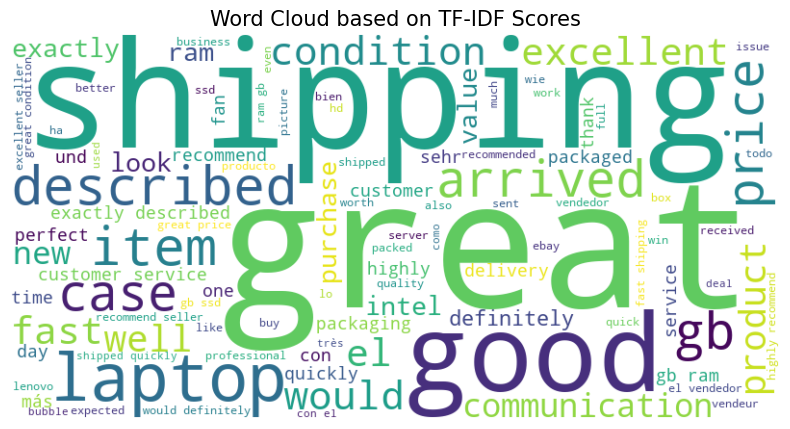

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


weights = dict(zip(tfidf_vectorizer.get_feature_names_out(), X_tfidf.toarray().sum(axis=0)))


wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=100, 
    colormap='viridis' 
).generate_from_frequencies(weights)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") 
plt.title("Word Cloud based on TF-IDF Scores", fontsize=15)
plt.show()

This cloud shows that the most influential words in the description of computers are confident in the seller (Great good) and technical specifications (Intel, GB, RAM)

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd


similarity_matrix = cosine_similarity(X_tfidf)


similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["titles"],
    columns=df["titles"]
)

print("Similarity Matrix Shape:", similarity_df.shape)
similarity_df.head(10)

Similarity Matrix Shape: (63, 63)


titles,,"Lenovo ThinkPad T14 G2 14"" Intel i5-1145G7 16GB RAM 256GB SSD Full HD Win 11 Pro",LENOVO IDEAPAD SLIM 7 14ITL05 Laptop Intel i5-1135G7 8GB RAM NO HD/OS/POWER (FL),"Asus Touch Chromebook Flip 14"" i3 1.80GHz/8GB/128GB SSD CX5400FM - w/Warranty",Perplexity Ai PRO 1 Year Code - GLOBAL,"Dell Latitude 7420 // Intel Core i7-1185G7, 16 Go RAM, 512 Go SSD, LTE","Microsoft Surface Laptop 4 // Intel Core i7-1185G7, 16 Go RAM, 512 Go SSD",Microsoft Surface Laptop 5 i7-1265U 16GB DDR5 512GB NVMe PARTS/REPAIR β Lap200,"Lenovo T14 GEN2 AMD RYZEN 5 PRO 5650U 14"" 16GB 256GB SSD WIN 11 Pro","HP Envy 15t-as100 15.6"" Touch Laptop Intel Core i7-6500U 8GB Ram NO HD/OS (FL)",...,"HP PRODESK 400 G4 MT I5-7500, 8GB, 500GB HDD - WIN11, rif.600",Dell Latitude 5400 i5 8th Gen 16GB 256GB SSD NVMe Windows 11 Home,"Lenovo IdeaPad 1 15AMN7 - Type 82VG - 128 GB Storage, 4 GB RAM","Microsoft Surface Pro 12"" 2110 Snapdragon X Plus 3.3GHz 16GB RAM 256GB SSD","ASUS VivoBook 15 OLED 120Hz, Intel Ultra 7 155H, 16GB RAM, 120Hz OLED Display",HP EliteBook 855 G8 Notebook PC Windows 11 Pro,"B Dell Latitude 7420 14"" Laptop i5-11th Gen 4.4GHz 250GB NVMe 8GB RAM 3733MHz",Linkedin Premium Career - 3 MONTHS -,"Asus F515E VivoBook 15.6”FullHD Laptop,Intel i3-1115G4,8GB RAM,128GB SSD, Win 11","Dell Latitude 5520 15"" FHD Intel Core i5-1135G7 2.4GHz 16GB RAM 512GB SSD, Good"
titles,,,,,,,,,,,,,,,,,,,,,
,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"Lenovo ThinkPad T14 G2 14"" Intel i5-1145G7 16GB RAM 256GB SSD Full HD Win 11 Pro",0.0,1.000000,0.413961,0.059829,0.022700,0.020801,0.020740,0.012895,0.089259,0.242904,...,0.022051,0.027753,0.037223,0.062585,0.144894,0.009989,0.026417,0.000000,0.089597,0.074160
LENOVO IDEAPAD SLIM 7 14ITL05 Laptop Intel i5-1135G7 8GB RAM NO HD/OS/POWER (FL),0.0,0.413961,1.000000,0.014658,0.000000,0.018374,0.034765,0.009947,0.016572,0.597220,...,0.013237,0.006799,0.059999,0.019482,0.125953,0.000000,0.023169,0.003420,0.071140,0.090602
"Asus Touch Chromebook Flip 14"" i3 1.80GHz/8GB/128GB SSD CX5400FM - w/Warranty",0.0,0.059829,0.014658,1.000000,0.892010,0.042931,0.042805,0.088406,0.098589,0.053284,...,0.042274,0.016893,0.006026,0.063373,0.068715,0.039499,0.056764,0.040658,0.060246,0.071991
Perplexity Ai PRO 1 Year Code - GLOBAL,0.0,0.022700,0.000000,0.892010,1.000000,0.044218,0.044088,0.070804,0.079406,0.000000,...,0.038451,0.000000,0.000000,0.054169,0.000000,0.054253,0.049181,0.049257,0.048822,0.058167
"Dell Latitude 7420 // Intel Core i7-1185G7, 16 Go RAM, 512 Go SSD, LTE",0.0,0.020801,0.018374,0.042931,0.044218,1.000000,0.989072,0.117126,0.115242,0.037145,...,0.221660,0.039388,0.034970,0.043784,0.010868,0.042142,0.049107,0.150896,0.153703,0.265181
"Microsoft Surface Laptop 4 // Intel Core i7-1185G7, 16 Go RAM, 512 Go SSD",0.0,0.020740,0.034765,0.042805,0.044088,0.989072,1.000000,0.130253,0.114904,0.054072,...,0.219564,0.034630,0.034867,0.053721,0.010836,0.042018,0.044835,0.150967,0.156790,0.260714
Microsoft Surface Laptop 5 i7-1265U 16GB DDR5 512GB NVMe PARTS/REPAIR β Lap200,0.0,0.012895,0.009947,0.088406,0.070804,0.117126,0.130253,1.000000,0.947030,0.010304,...,0.128592,0.006188,0.006584,0.041121,0.006930,0.029263,0.036836,0.137618,0.139414,0.175741
"Lenovo T14 GEN2 AMD RYZEN 5 PRO 5650U 14"" 16GB 256GB SSD WIN 11 Pro",0.0,0.089259,0.016572,0.098589,0.079406,0.115242,0.114904,0.947030,1.000000,0.006630,...,0.129576,0.010197,0.008669,0.034762,0.006924,0.033051,0.030903,0.136831,0.147219,0.179059


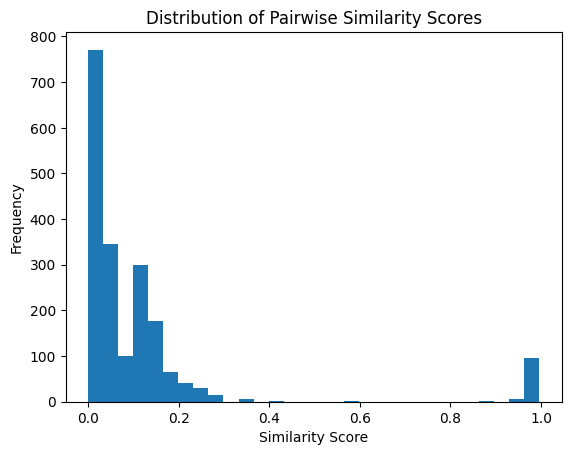

In [29]:
import numpy as np
import matplotlib.pyplot as plt

all_scores = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

plt.figure()
plt.hist(all_scores, bins=30)
plt.title("Distribution of Pairwise Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.show()

The similarity distribution shows that the majority of product pairs have low similarity scores (between 0.0 and 0.2), indicating that most scraped listings are distinct.
However, a small cluster of high similarity scores (above 0.9) suggests the presence of near-duplicate or highly similar product listings.
This observation justifies the use of a 0.90 threshold for duplicate detection.

In [30]:
threshold = 0.90
duplicates = []

for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i][j] > threshold:
            duplicates.append((
                df.iloc[i]["titles"],
                df.iloc[j]["titles"],
                similarity_matrix[i][j]
            ))

duplicates_df = pd.DataFrame(duplicates, columns=["Product 1", "Product 2", "Similarity Score"])

print("Potential Duplicates:")
print(duplicates_df.sort_values(by="Similarity Score", ascending=False))

Potential Duplicates:
                                            Product 1  \
27     Canva Premium & Graphic & Professional Designs   
91  Dell Vostro 5590 15.6" Laptop - i7-10510U 16GB...   
87  Good condition - Lenovo ThinkPad T470s 14" ,In...   
20  HP 15-DY1044NR 15.6" Laptop Intel Core i3-1005...   
93  Ordinateur portable HP EliteBook 645 G9 14" AM...   
..                                                ...   
28  Panasonic Toughbook FZ-55 Core i5-8365U/8GB/51...   
78  Dell Latitude 7490 14" Laptop i7 8th Gen 1TB S...   
99     HP EliteBook 855 G8 Notebook PC Windows 11 Pro   
19  Microsoft Surface Laptop 5 i7-1265U 16GB DDR5 ...   
94  Microsoft Surface Laptop 7 13.8" Intel Ultra 7...   

                                            Product 2  Similarity Score  
27  ⚡️HP EliteBook 8560w 🕹️ Retro Workstation | NV...          0.995895  
91  HP 15.6 FHD Intel Core 7 150U AI Laptop (2025)...          0.992770  
87  🖱️ Lenovo ThinkPad L450 – Potente, Affidabile,...          0.992322

The similarity distribution shows extremely high scores (0.95–1.00) across many product pairs.
This indicates strong lexical overlap between product titles.
A threshold of 0.90 successfully isolates highly similar listings, though further text normalization may reduce false positives.

In [31]:
duplicates = []

for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i][j] > threshold:
            duplicates.append((
                df.iloc[i]["titles"],
                df.iloc[j]["titles"],
                similarity_matrix[i][j]
            ))

duplicates_df = pd.DataFrame(
    duplicates,
    columns=["Product 1", "Product 2", "Similarity"]
)

duplicates_df.head(10)

,Product 1,Product 2,Similarity
0,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...",Microsoft Surface Laptop 4 // Intel Core i7-11...,0.989072
1,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...",Notebook 15.6 (SSD 256GB) | 8GB RAM | Office 2...,0.976174
2,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Dell Latitude 3190 Laptop 11.6"" HD Intel Celer...",0.980149
3,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...",Panasonic Toughbook CF-33 i5 7th 16GB RAM Dual...,0.974056
4,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Fujitsu Lifebook AH532/G21 Intel Core i5, 4 Go...",0.990191
5,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Lenovo ThinkPad T14 Gen 6/14""/AMD Ryzen AI 5 P...",0.964130
6,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Dell Latitude 5320 TOUCH , i5-1145G7 2.60GHz, ...",0.971946
7,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Lenovo ThinkPad X390 13,3 pouces (33,8 cm) (50...",0.985895
8,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","Good condition - Lenovo ThinkPad T470s 14"" ,In...",0.979144
9,"Dell Latitude 7420 // Intel Core i7-1185G7, 16...","🖱️ Lenovo ThinkPad L450 – Potente, Affidabile,...",0.979101


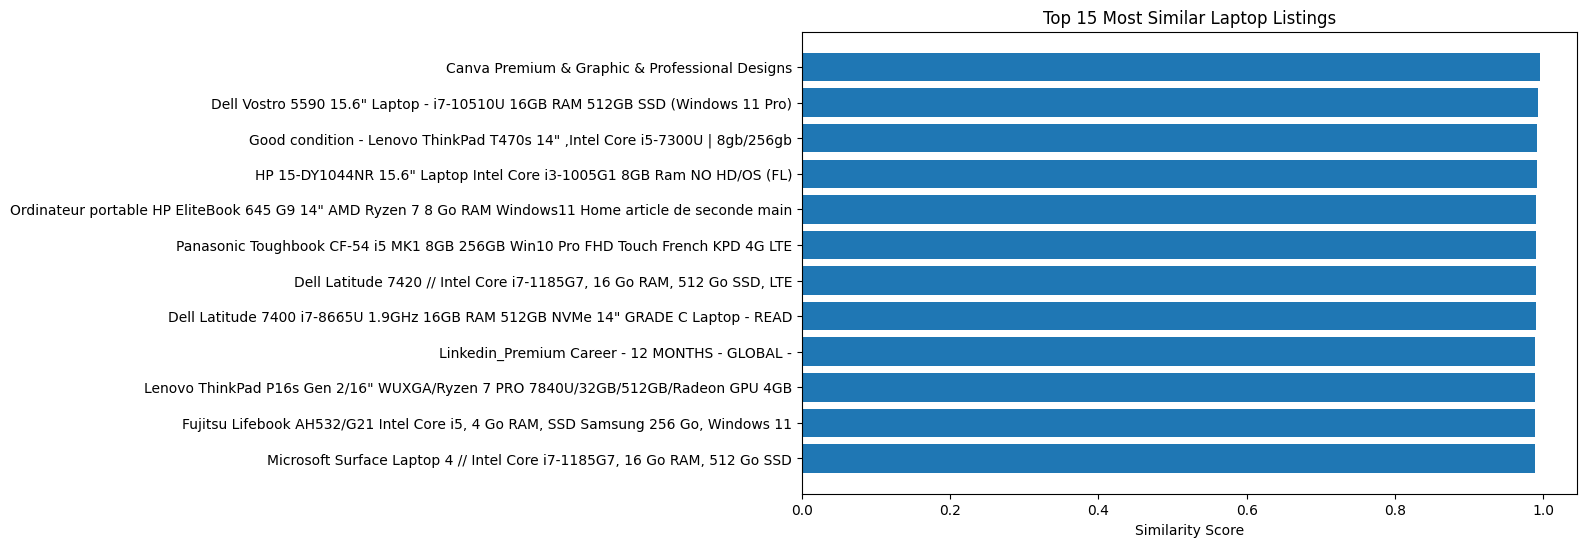

In [32]:
top_pairs = duplicates_df.sort_values(
    by="Similarity", ascending=False
).head(15)

plt.figure(figsize=(10,6))
plt.barh(
    top_pairs["Product 1"],
    top_pairs["Similarity"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Most Similar Laptop Listings")
plt.xlabel("Similarity Score")
plt.show()

The analysis shows a high degree of hardware convergence, where identical technical specs (CPU, RAM) result in near-perfect similarity scores, identifying different brands as substitutes. Recurring patterns in listings reveal standardized seller templates, highlighting the model’s ability to match products based on performance rather than brand.
